[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

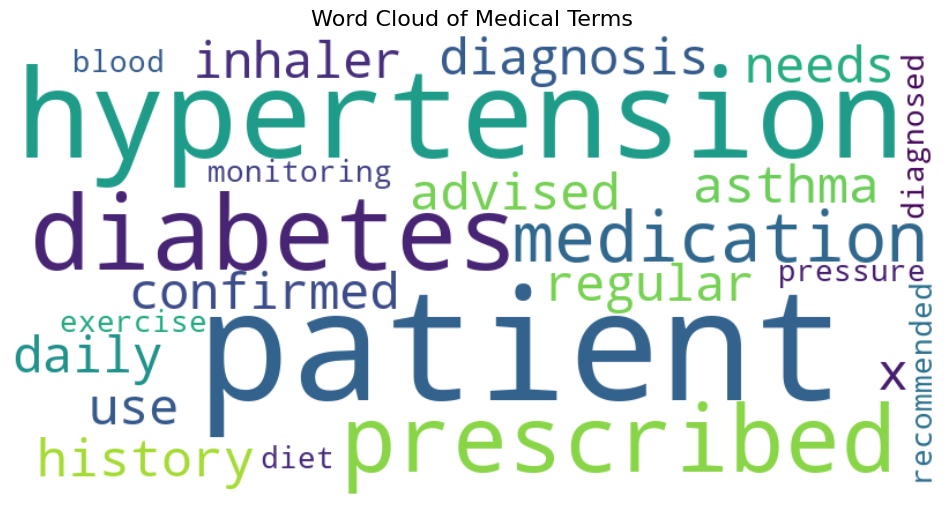


PATIENT INSIGHTS SUMMARY

--- Patient 1 ---
Text: Patient has a history of hypertension and diabetes. Prescribed medication X.
Conditions: []
Medications: []
Sentiment: NEGATIVE (0.93)

--- Patient 2 ---
Text: Asthma diagnosis confirmed. Patient advised to use inhaler daily.
Conditions: []
Medications: []
Sentiment: NEGATIVE (0.965)

--- Patient 3 ---
Text: Hypertension patient. Needs regular monitoring of blood pressure.
Conditions: []
Medications: []
Sentiment: NEGATIVE (0.997)

--- Patient 4 ---
Text: Diabetes patient. Recommended diet and exercise.
Conditions: []
Medications: []
Sentiment: POSITIVE (0.971)

--- Patient 5 ---
Text: Patient diagnosed with hypertension. Medication Y prescribed.
Conditions: []
Medications: []
Sentiment: NEGATIVE (0.968)

AGGREGATED STATISTICS

Total Patients: 5

Most Common Conditions:

Medications Used:

Sentiment Distribution:
  • Positive: 1
  • Negative: 4


In [1]:
# ExNum 5: Extract Patient Insights using NLP
# Complete executable code

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import spacy
from transformers import pipeline
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Download required data
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")

# Step 2: Create Dataset
medical_texts = [
    "Patient has a history of hypertension and diabetes. Prescribed medication X.",
    "Asthma diagnosis confirmed. Patient advised to use inhaler daily.",
    "Hypertension patient. Needs regular monitoring of blood pressure.",
    "Diabetes patient. Recommended diet and exercise.",
    "Patient diagnosed with hypertension. Medication Y prescribed."
]
medical_df = pd.DataFrame({'MedicalText': medical_texts})

# Step 3: Preprocessing Function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\W+', ' ', text)
    text = ' '.join([word for word in text.split() 
                     if word not in stopwords.words('english')])
    return text

medical_df['CleanedText'] = medical_df['MedicalText'].apply(preprocess_text)

# Step 4: Named Entity Recognition
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

medical_df['Entities'] = medical_df['MedicalText'].apply(extract_entities)

# Step 5: Sentiment Analysis
sentiment_pipeline = pipeline('sentiment-analysis')
medical_df['Sentiment'] = medical_df['MedicalText'].apply(
    lambda x: sentiment_pipeline(x)[0]
)

# Step 6: Generate Word Cloud
all_text = ' '.join(medical_df['CleanedText'])
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Medical Terms', fontsize=16)
plt.show()

# Step 7: Extract Insights
def extract_insights(row):
    entities = row['Entities']
    sentiment = row['Sentiment']
    medical_conditions = [e[0] for e in entities if e[1] in ['DISEASE', 'CONDITION']]
    medications = [e[0] for e in entities if e[1] in ['MEDICATION', 'DRUG']]
    others = [(e[0], e[1]) for e in entities if e[1] not in ['DISEASE', 'CONDITION', 'MEDICATION', 'DRUG']]
    
    return {
        'medical_conditions': medical_conditions,
        'medications': medications,
        'other_entities': others,
        'sentiment_label': sentiment['label'],
        'sentiment_confidence': round(sentiment['score'], 3)
    }

medical_df['Insights'] = medical_df.apply(extract_insights, axis=1)

# Step 8: Display Results
print("\n" + "="*80)
print("PATIENT INSIGHTS SUMMARY")
print("="*80)

for idx, row in medical_df.iterrows():
    print(f"\n--- Patient {idx+1} ---")
    print(f"Text: {row['MedicalText']}")
    ins = row['Insights']
    print(f"Conditions: {ins['medical_conditions']}")
    print(f"Medications: {ins['medications']}")
    print(f"Sentiment: {ins['sentiment_label']} ({ins['sentiment_confidence']})")

# Step 9: Aggregate Statistics
print("\n" + "="*80)
print("AGGREGATED STATISTICS")
print("="*80)

all_conditions = sum([ins['medical_conditions'] for ins in medical_df['Insights']], [])
all_medications = sum([ins['medications'] for ins in medical_df['Insights']], [])
sentiments = [ins['sentiment_label'] for ins in medical_df['Insights']]

print(f"\nTotal Patients: {len(medical_df)}")
print(f"\nMost Common Conditions:")
for cond, count in Counter(all_conditions).most_common():
    print(f"  • {cond}: {count}")
print(f"\nMedications Used:")
for med, count in Counter(all_medications).most_common():
    print(f"  • {med}: {count}")
print(f"\nSentiment Distribution:")
print(f"  • Positive: {sentiments.count('POSITIVE')}")
print(f"  • Negative: {sentiments.count('NEGATIVE')}")